In [9]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# ==========================================================
# STEP 1: CREATE SOURCE DATA (Area, Location, Rooms)
# ==========================================================
raw_data = {
    "Area_SqFt": [1200, 1500, 900, 2100, 1100, 850, 2500, 1800, 950, 1600],
    "Rooms": [3, 4, 2, 5, 3, 2, 5, 4, 2, 3],
    "Location": [
        "Downtown",
        "Suburb",
        "Downtown",
        "Suburb",
        "Rural",
        "Rural",
        "Downtown",
        "Suburb",
        "Rural",
        "Downtown",
    ],
    "Price_USD": [
        310000,
        280000,
        240000,
        410000,
        190000,
        150000,
        490000,
        460000,
        175000,
        390000,
    ],
}
df = pd.DataFrame(raw_data)
print("--- Raw Initial Dataset View ---")
print(df.head(3), "\n")

# ==========================================================
# STEP 2: CONVERT TEXT LOCATION TO NUMBERS (One-Hot Encoding)
# ==========================================================
# This creates new true/false numerical binary columns for categorical data
df_encoded = pd.get_dummies(df, columns=["Location"], drop_first=True)

# ==========================================================
# STEP 3: SEPARATE FEATURES (X) AND TARGET VARIABLE (y)
# ==========================================================
X = df_encoded.drop(columns=["Price_USD"])
y = df_encoded["Price_USD"]

# ==========================================================
# STEP 4: MODEL PIPELINE (Split, Train, and Evaluate)
# ==========================================================
# Small dataset test_size adjusted slightly to make sure it runs smoothly
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# ==========================================================
# STEP 5: INTERPRET MODEL METRICS & MATHEMATICAL EQUATION
# ==========================================================
print("=== Multiple Linear Regression Results ===")
print(f"Base Intercept Value : ${model.intercept_:.2f}")

for feature, weight in zip(X.columns, model.coef_):
    print(f"Weight for {feature:18}: ${weight:.2f}")

print(f"\nModel Variance Accuracy (R2 Score): {r2_score(y_test, y_pred):.4f}")


--- Raw Initial Dataset View ---
   Area_SqFt  Rooms  Location  Price_USD
0       1200      3  Downtown     310000
1       1500      4    Suburb     280000
2        900      2  Downtown     240000 

=== Multiple Linear Regression Results ===
Base Intercept Value : $155123.77
Weight for Area_SqFt         : $235.21
Weight for Rooms             : $-49905.70
Weight for Location_Rural    : $-89685.66
Weight for Location_Suburb   : $45799.61

Model Variance Accuracy (R2 Score): -0.0323


In [2]:
# Multiple Linear Regression - Boston Housing Dataset

# Step 1: Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Step 2: Load dataset
df = pd.read_csv("BostonHousing.csv")

# Step 3: Display first 5 rows
print("First 5 rows:")
print(df.head())

# Step 4: Check missing values
print("\nMissing values:")
print(df.isnull().sum())

# Step 5: Fill missing values with column mean
df["rm"] = df["rm"].fillna(df["rm"].mean())

# Step 6: Separate input and output
X = df.drop("medv", axis=1)
y = df["medv"]

# Step 7: Split data into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 8: Create Multiple Linear Regression model
model = LinearRegression()

# Step 9: Train the model
model.fit(X_train, y_train)

# Step 10: Predict test data
y_pred = model.predict(X_test)

# Step 11: Display intercept
print("\nIntercept:")
print(model.intercept_)

# Step 12: Display coefficients
print("\nCoefficients:")
print(model.coef_)

# Step 13: Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

# Step 14: Calculate R2 Score
r2 = r2_score(y_test, y_pred)

print("\nMean Squared Error:", mse)
print("R2 Score:", r2)

First 5 rows:
      crim    zn  indus  chas    nox     rm   age     dis  rad  tax  ptratio  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        b  lstat  medv  
0  396.90   4.98  24.0  
1  396.90   9.14  21.6  
2  392.83   4.03  34.7  
3  394.63   2.94  33.4  
4  396.90   5.33  36.2  

Missing values:
crim       0
zn         0
indus      0
chas       0
nox        0
rm         5
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

Intercept:
30.29636237179078

Coefficients:
[-1.13050524e-01  3.02091590e-02  4.17263876e-02  2.78758593e+00
 -1.71889290e+01  4.42919339e+00 

Multiple Linear Regression Results
-----------------------------------
Mean Squared Error: 24.404825188146056
R2 Score: 0.6672089705941937


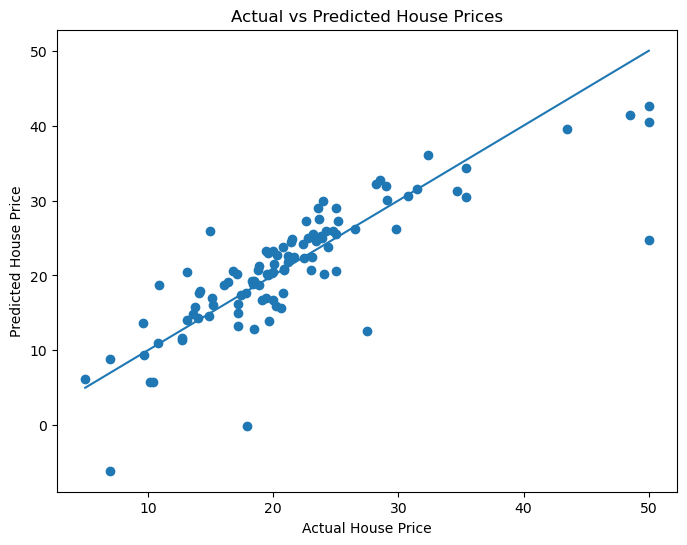

In [7]:
# Multiple Linear Regression with Graph
# Boston Housing Dataset

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load dataset
df = pd.read_csv("BostonHousing.csv")

# 2. Handle missing values
df["rm"] = df["rm"].fillna(df["rm"].mean())

# 3. Define X and y
X = df.drop("medv", axis=1)
y = df["medv"]

# 4. Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5. Create model
model = LinearRegression()

# 6. Train model
model.fit(X_train, y_train)

# 7. Make predictions
y_pred = model.predict(X_test)

# 8. Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Multiple Linear Regression Results")
print("-----------------------------------")
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

# 9. Actual vs Predicted Graph
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

MULTIPLE LINEAR REGRESSION
---------------------------
Mean Squared Error: 24.404825188146056
R2 Score: 0.6672089705941937


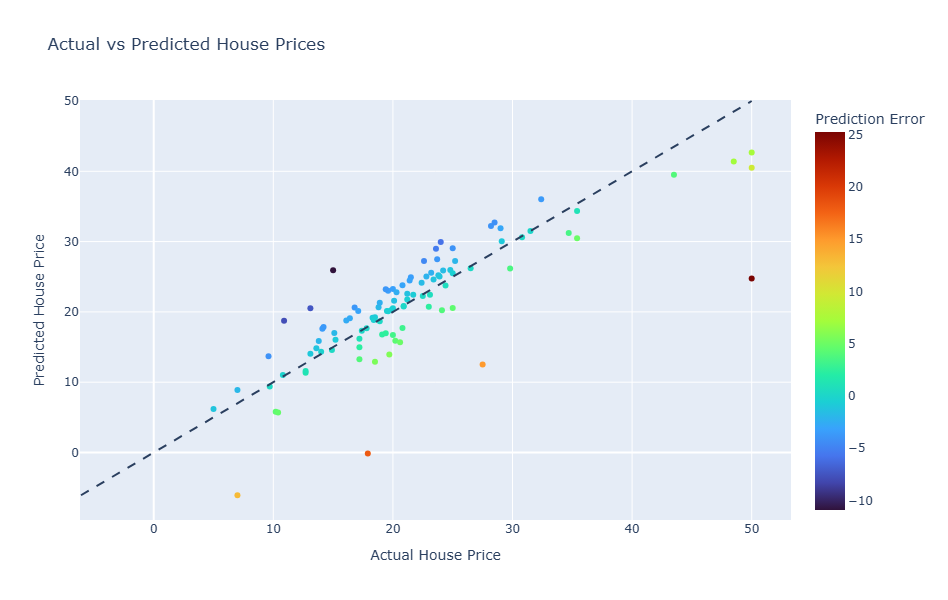

In [6]:
# Multiple Linear Regression - Dynamic Graph

import pandas as pd
import numpy as np
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load dataset
df = pd.read_csv("BostonHousing.csv")

# 2. Handle missing values
df["rm"] = df["rm"].fillna(df["rm"].mean())

# 3. Independent and dependent variables
X = df.drop("medv", axis=1)
y = df["medv"]

# 4. Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5. Create model
model = LinearRegression()

# 6. Train model
model.fit(X_train, y_train)

# 7. Predict
y_pred = model.predict(X_test)

# 8. Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MULTIPLE LINEAR REGRESSION")
print("---------------------------")
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

# 9. Create result dataframe
result = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

# 10. Add error
result["Error"] = result["Actual"] - result["Predicted"]

# 11. Interactive graph
fig = px.scatter(
    result,
    x="Actual",
    y="Predicted",
    color="Error",
    hover_data=["Actual", "Predicted", "Error"],
    title="Actual vs Predicted House Prices",
    labels={
        "Actual": "Actual House Price",
        "Predicted": "Predicted House Price",
        "Error": "Prediction Error"
    },
    color_continuous_scale="Turbo"
)

# 12. Add perfect prediction line
min_value = min(result["Actual"].min(), result["Predicted"].min())
max_value = max(result["Actual"].max(), result["Predicted"].max())

fig.add_shape(
    type="line",
    x0=min_value,
    y0=min_value,
    x1=max_value,
    y1=max_value,
    line=dict(dash="dash")
)

# 13. Graph settings
fig.update_layout(
    width=900,
    height=600
)

# 14. Display interactive graph
fig.show()

POLYNOMIAL REGRESSION
---------------------
Polynomial Degree: 2
Mean Squared Error: 35.480358482252456
R2 Score: 0.5161798975421057


C:\Users\anits-csm\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning:

X does not have valid feature names, but PolynomialFeatures was fitted with feature names



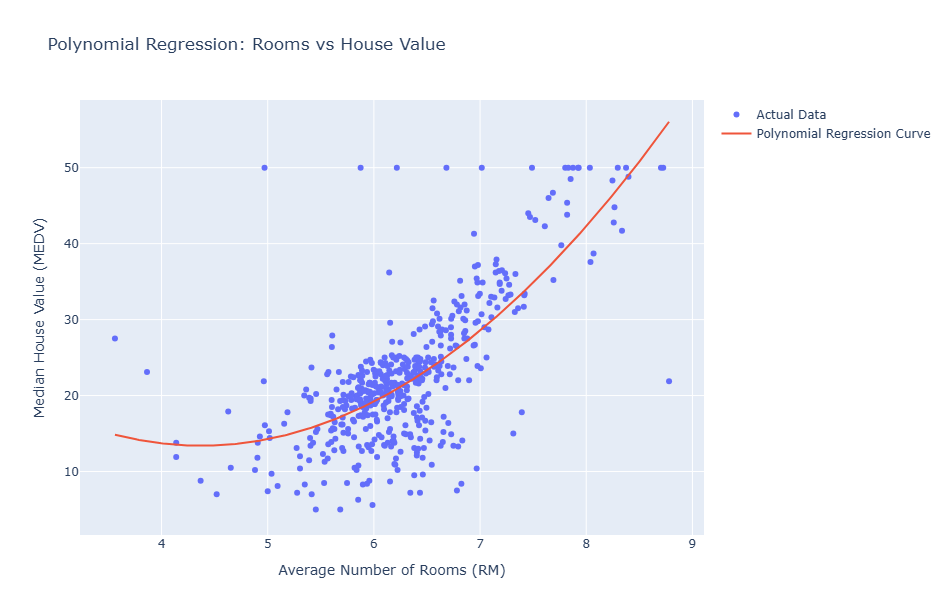

In [8]:
# Polynomial Regression
# Boston Housing Dataset

import pandas as pd
import numpy as np
import plotly.graph_objects as go

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# 1. Load dataset
df = pd.read_csv("BostonHousing.csv")

# 2. Handle missing values
df["rm"] = df["rm"].fillna(df["rm"].mean())

# 3. Select input and output
X = df[["rm"]]
y = df["medv"]

# 4. Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5. Create polynomial features
poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# 6. Create model
model = LinearRegression()

# 7. Train model
model.fit(X_train_poly, y_train)

# 8. Predict
y_pred = model.predict(X_test_poly)

# 9. Calculate performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("POLYNOMIAL REGRESSION")
print("---------------------")
print("Polynomial Degree: 2")
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

# 10. Create smooth curve for graph
X_curve = np.linspace(
    df["rm"].min(),
    df["rm"].max(),
    300
).reshape(-1, 1)

X_curve_poly = poly.transform(X_curve)

y_curve = model.predict(X_curve_poly)

# 11. Create interactive graph
fig = go.Figure()

# Actual data points
fig.add_trace(
    go.Scatter(
        x=df["rm"],
        y=df["medv"],
        mode="markers",
        name="Actual Data",
        text=[
            f"Rooms: {x:.2f}<br>House Value: {y:.2f}"
            for x, y in zip(df["rm"], df["medv"])
        ],
        hovertemplate="%{text}<extra></extra>"
    )
)

# Polynomial curve
fig.add_trace(
    go.Scatter(
        x=X_curve.flatten(),
        y=y_curve,
        mode="lines",
        name="Polynomial Regression Curve",
        hovertemplate=
        "Rooms: %{x:.2f}<br>Predicted Value: %{y:.2f}"
        "<extra></extra>"
    )
)

# 12. Graph title and labels
fig.update_layout(
    title="Polynomial Regression: Rooms vs House Value",
    xaxis_title="Average Number of Rooms (RM)",
    yaxis_title="Median House Value (MEDV)",
    width=950,
    height=600
)

# 13. Display graph
fig.show()